# HW3 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [1]:
%load_ext autoreload
%autoreload 2

from hw3_loader import HW3DataLoader
from model import svm_classifier, svm_regressor
from model import evaluate_classifier, evaluate_regressor
from utils import (
    plot_classification_results,
    plot_regression_results,
    plot_residuals,
    explore_classification_data,
    apply_pca,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## Data Loading

In [2]:
loader = HW3DataLoader()
# X_clf, y_clf = loader.get_heart_disease_data('data/heart.csv')
X_clf, y_clf = loader.get_heart_disease_data()
# df_aging = loader.get_aging_data(pickle_path="data/GSE139307.pkl")
df_aging = loader.get_aging_data()

# TODO: Inspect dataset shapes and missing values
print("Heart dataset X shape:", X_clf.shape)
print("Heart dataset y shape:", y_clf.shape)
print("Heart dataset missing values: ", X_clf.isnull().sum().sum())

print("Aging dataset shape:", df_aging.shape)
print("Aging dataset missing values: ",df_aging.isnull().sum().sum())


# TODO: Print basic summary statistics for each dataset
print("Heart dataset X summary statistics: ", X_clf.describe())
print("Heart dataset y summary statistics: ", y_clf.describe())

print("Aging dataset summary statistics:")
print(df_aging.iloc[:, :500].describe())
# NOTE: doing first 500 features so it won't run forever since the dataframe is huge


Successfully loaded heart disease data with 1025 rows


c:\Users\lalaf\OneDrive\Brown\Spring 2026\ML for Bio and Health\Homeworks\homework-3-veronicafigueroa\src\hw3_loader.py:84: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(f)


Heart dataset X shape: (1025, 13)
Heart dataset y shape: (1025,)
Heart dataset missing values:  0
Aging dataset shape: (37, 485516)
Aging dataset missing values:  526
Heart dataset X summary statistics:                 age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.

## Classification Task (Heart Disease)

Exploring classification dataset...


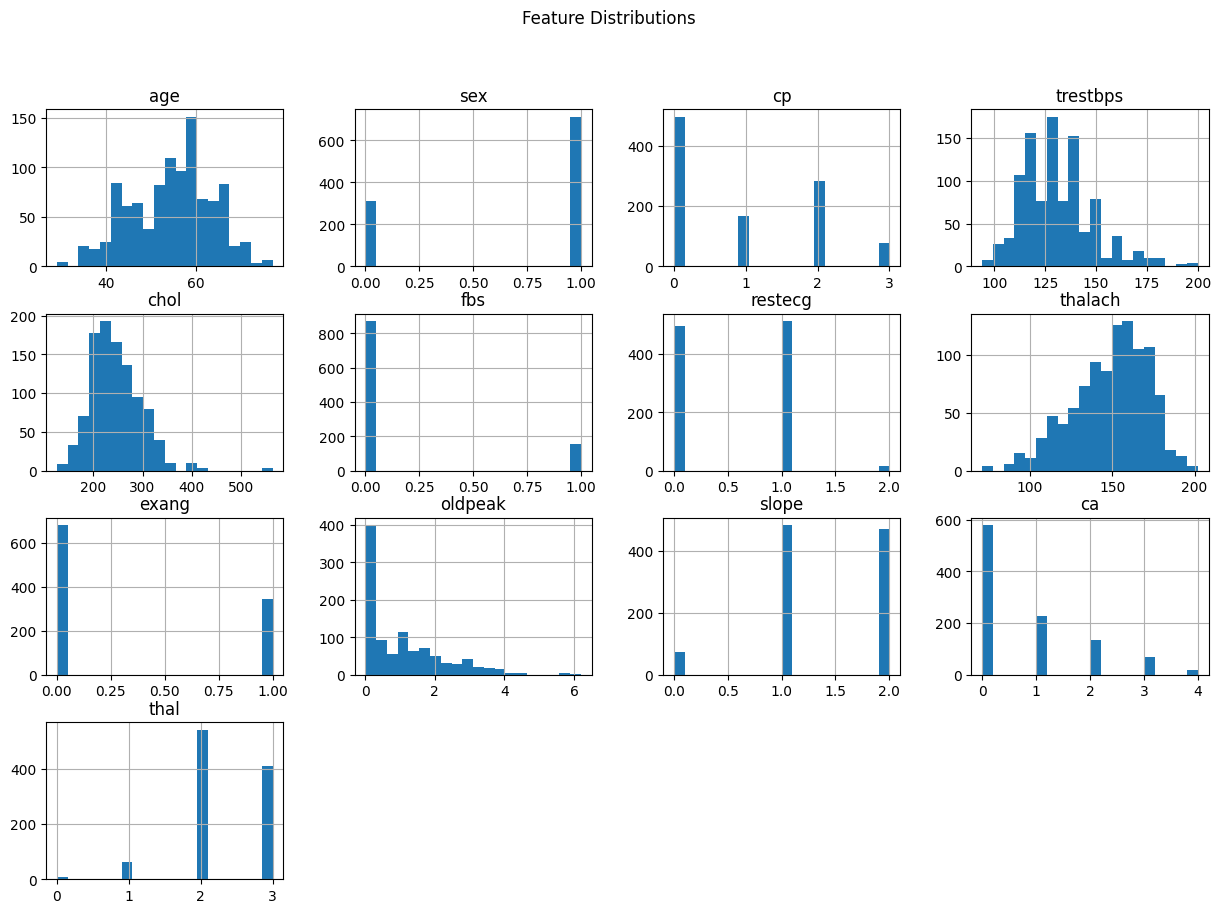

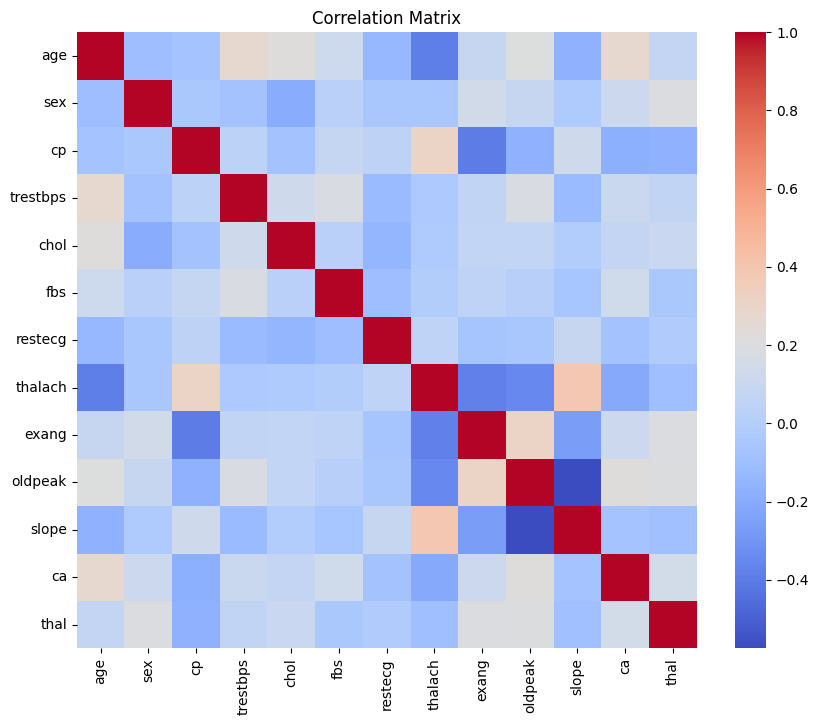

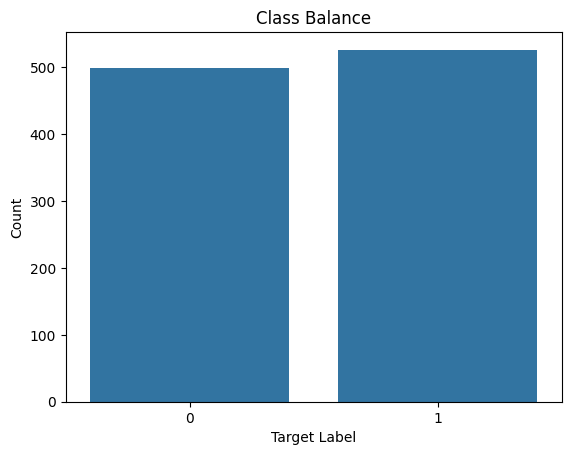

In [3]:
# TODO: Use explore_classification_data to show histograms, correlations, and class balance
# Use utils

explore_classification_data(X_clf, y_clf)

In [4]:
# TODO: Split X_clf and y_clf into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (820, 13)
X_test shape:  (205, 13)
y_train shape:  (820,)
y_test shape:  (205,)


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVM)

In [5]:
# TODO: Build a leakage-free pipeline for classification
# Example skeleton:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    # ("pca", ...),
    ("model", svm_classifier(kernel="linear", C=1, degree=3, gamma="scale")),
])


### Kernel Experiments

In [6]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model

kernels = ["linear", "poly", "rbf"]
C_vals = [0.1, 1, 10]
degrees = [2, 3, 4]
gammas = ["scale", "auto"]

results = []

for kernel in kernels:
    for C_val in C_vals:
        if kernel == "linear":
            pipeline.set_params(
                model__kernel=kernel, 
                model__C = C_val
            )
            pipeline.fit(X_train, y_train)

            metrics = evaluate_classifier(pipeline, X_test, y_test)

            results.append({
                "kernel": kernel,
                "C": C_val,
                "degree": None,
                "gamma": None,
                **metrics
            })

        elif kernel == "poly":
            for degree in degrees:
                pipeline.set_params(
                    model__kernel=kernel,
                    model__C = C_val,
                    model__degree = degree
                )
                pipeline.fit(X_train, y_train)

                metrics = evaluate_classifier(pipeline, X_test, y_test)

                results.append({
                    "kernel": kernel,
                    "C": C_val,
                    "degree": degree,
                    "gamma": None,
                    **metrics
                })

        else:
            for gamma in gammas:
                pipeline.set_params(
                    model__kernel=kernel,
                    model__C = C_val,
                    model__gamma = gamma
                )
                pipeline.fit(X_train, y_train)

                metrics = evaluate_classifier(pipeline, X_test, y_test)

                results.append({
                    "kernel": kernel,
                    "C": C_val,
                    "degree": None,
                    "gamma": gamma,
                    **metrics
                })

results_df = pd.DataFrame(results)
print(results_df.sort_values("recall", ascending=False))
# choosing Recall since it's used to capture all possible positives
# for disease testing, it's better to misclassify as a FN than a FP

    kernel     C  degree  gamma  accuracy  precision    recall        f1
7     poly   1.0     3.0    NaN  0.907317   0.855932  0.980583  0.914027
5     poly   0.1     4.0    NaN  0.712195   0.641026  0.970874  0.772201
17     rbf  10.0     NaN   auto  0.975610   0.980392  0.970874  0.975610
16     rbf  10.0     NaN  scale  0.975610   0.980392  0.970874  0.975610
8     poly   1.0     4.0    NaN  0.882927   0.826446  0.970874  0.892857
10    poly  10.0     3.0    NaN  0.960976   0.952381  0.970874  0.961538
4     poly   0.1     3.0    NaN  0.804878   0.736842  0.951456  0.830508
14     rbf   1.0     NaN  scale  0.887805   0.850877  0.941748  0.894009
15     rbf   1.0     NaN   auto  0.887805   0.850877  0.941748  0.894009
11    poly  10.0     4.0    NaN  0.946341   0.950980  0.941748  0.946341
3     poly   0.1     2.0    NaN  0.731707   0.666667  0.932039  0.777328
0   linear   0.1     NaN    NaN  0.819512   0.761905  0.932039  0.838428
1   linear   1.0     NaN    NaN  0.814634   0.76000

### Classification Metrics and Visuals

Accuracy:  0.975609756097561
F1:  0.975609756097561
ROC-AUC:  0.9800114220445459
Confusion Matrix:
 [[100   2]
 [  3 100]]


Text(0, 0.5, 'Precision')

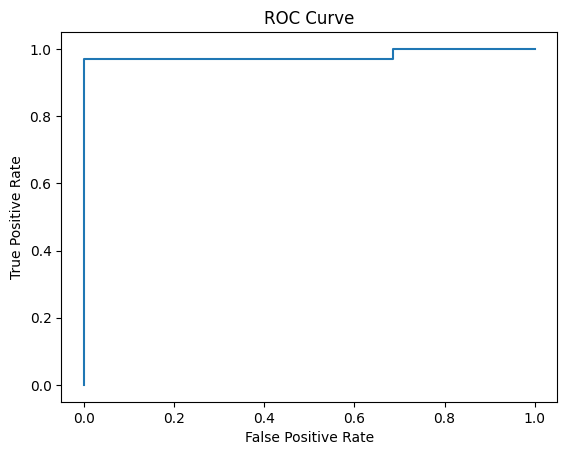

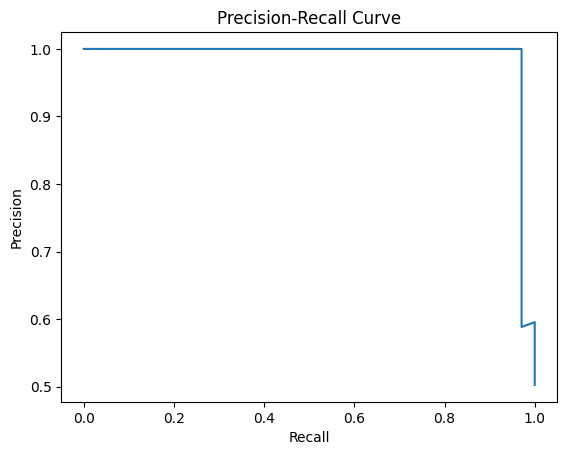

In [7]:
# TODO: Compute accuracy and F1

# NOTE: computing this for best model from above, hardcoding parameters
pipeline.set_params(
    model__kernel = "rbf",
    model__C = 10,
    model__gamma = "auto"
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy: ", accuracy)
print("F1: ", f1)

# TODO: Compute ROC-AUC or PR-AUC
y_test_scores = pipeline.decision_function(X_test)
roc_auc = roc_auc_score(y_test, y_test_scores)
print("ROC-AUC: ", roc_auc)


# TODO: Plot confusion matrix and ROC/PR curve
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

fpr, tpr, thresholds = roc_curve(y_test, y_test_scores)
plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

prec, recall, thresholds = precision_recall_curve(y_test, y_test_scores)
plt.figure()
plt.plot(recall, prec)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")




### Hyperparameter Sensitivity

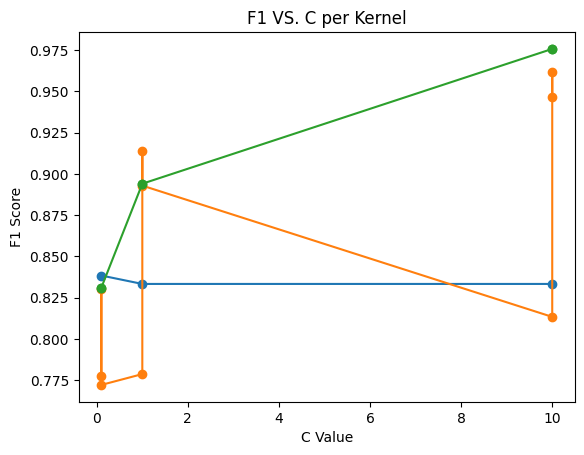

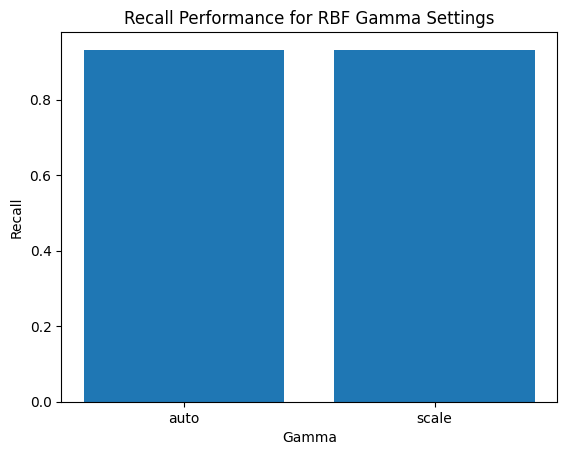

In [8]:
# TODO: Make 1-2 concise visuals of performance vs C/gamma/degree
# Example: line plot of F1 vs C for a fixed kernel

plt.figure()
for kernel in results_df["kernel"].unique():
    kernel_type =results_df[results_df["kernel"] == kernel]
    plt.plot(kernel_type["C"], kernel_type["f1"], marker="o", label=kernel)

plt.title("F1 VS. C per Kernel")
plt.xlabel("C Value")
plt.ylabel("F1 Score")

# Example #2 - Recall performance for different gammas (RBF kernel only)
rbf_df = results_df[results_df["kernel"] == "rbf"]
gamma_recall = rbf_df.groupby("gamma")["recall"].mean()
plt.figure()

plt.bar(gamma_recall.index.astype(str), gamma_recall.values)

plt.xlabel("Gamma")
plt.ylabel("Recall")
plt.title("Recall Performance for RBF Gamma Settings")

plt.show()


## Regression Task (Biological Aging)

In [64]:
# TODO: Separate target column "target" from features
print(df_aging.keys())
X_reg = df_aging.drop(columns=["age"])
y_reg = df_aging["age"]
print("X shape: ", X_reg.shape)
print("y shape: ", y_reg.shape)

# TODO: Handle missing values with column-wise mean imputation (do not drop rows/cols)

# Using mean imputation for numeric columns and most frequent imputation for string columns
num_cols = X_reg.select_dtypes(include=[np.number]).columns
cat_cols = X_reg.select_dtypes(exclude=[np.number]).columns

num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_num = pd.DataFrame(
    num_imputer.fit_transform(X_reg[num_cols]),
    columns=num_imputer.get_feature_names_out(num_cols),
    index=X_reg.index
)

X_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_reg[cat_cols]),
    columns=cat_imputer.get_feature_names_out(cat_cols),
    index=X_reg.index
)
X_cat = pd.get_dummies(X_cat, columns=cat_cols)

X_reg = pd.concat([X_num, X_cat], axis=1)


# X_reg[num_cols] = num_imputer.fit_transform(X_reg[num_cols])
# X_reg[cat_cols] = cat_imputer.fit_transform(X_reg[cat_cols])

# TODO: Split X_reg and y_reg into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
print("X_train shape: ", X_train.shape)
print("y_test shape", y_test.shape)

Index(['dataset', 'tissue_type', 'age', 'gender', 'cg00000029', 'cg00000108',
       'cg00000109', 'cg00000165', 'cg00000236', 'cg00000289',
       ...
       'ch.X.93511680F', 'ch.X.938089F', 'ch.X.94051109R', 'ch.X.94260649R',
       'ch.X.967194F', 'ch.X.97129969R', 'ch.X.97133160R', 'ch.X.97651759F',
       'ch.X.97737721F', 'ch.X.98007042R'],
      dtype='object', length=485516)
X shape:  (37, 485515)
y shape:  (37,)


c:\Users\lalaf\OneDrive\Brown\Spring 2026\ML for Bio and Health\Homeworks\homework-3-veronicafigueroa\.hw3\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['cg01550828']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


X_train shape:  (29, 485514)
y_test shape (8,)


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVR)

### WITHOUT PCA

In [46]:
# TODO: Build a leakage-free pipeline for regression
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    # ("pca", PCA(n_components=10)),
    ("model", svm_regressor(kernel="linear", C=1, degree=3, gamma="scale")),
])

### Kernel Experiments

In [44]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model

kernels = ["linear", "poly", "rbf"]
C_vals = [0.1, 1, 10]
degrees = [2, 3, 4]
gammas = ["scale", "auto"]

results = []

for kernel in kernels:
    for C_val in C_vals:
        if kernel == "linear":
            pipeline.set_params(
                model__kernel=kernel, 
                model__C = C_val
            )
            pipeline.fit(X_train, y_train)

            metrics = evaluate_regressor(pipeline, X_test, y_test)

            results.append({
                "kernel": kernel,
                "C": C_val,
                "degree": None,
                "gamma": None,
                **metrics
            })

        elif kernel == "poly":
            for degree in degrees:
                pipeline.set_params(
                    model__kernel=kernel,
                    model__C = C_val,
                    model__degree = degree
                )
                pipeline.fit(X_train, y_train)

                metrics = evaluate_regressor(pipeline, X_test, y_test)

                results.append({
                    "kernel": kernel,
                    "C": C_val,
                    "degree": degree,
                    "gamma": None,
                    **metrics
                })

        else:
            for gamma in gammas:
                pipeline.set_params(
                    model__kernel=kernel,
                    model__C = C_val,
                    model__gamma = gamma
                )
                pipeline.fit(X_train, y_train)

                metrics = evaluate_regressor(pipeline, X_test, y_test)

                results.append({
                    "kernel": kernel,
                    "C": C_val,
                    "degree": None,
                    "gamma": gamma,
                    **metrics
                })

results_df = pd.DataFrame(results)
print(results_df.sort_values("r2", ascending=False))

    kernel     C  degree  gamma       mae      rmse        r2
15     rbf   1.0     NaN   auto  4.198859  5.694251  0.001843
14     rbf   1.0     NaN  scale  4.198860  5.694251  0.001843
8     poly   1.0     4.0    NaN  4.114197  5.695620  0.001363
7     poly   1.0     3.0    NaN  4.114776  5.699521 -0.000005
4     poly   0.1     3.0    NaN  3.939681  5.718034 -0.006512
12     rbf   0.1     NaN  scale  3.952378  5.718620 -0.006718
13     rbf   0.1     NaN   auto  3.952378  5.718620 -0.006718
5     poly   0.1     4.0    NaN  3.939970  5.720835 -0.007498
3     poly   0.1     2.0    NaN  3.947120  5.724352 -0.008737
6     poly   1.0     2.0    NaN  4.142532  5.730862 -0.011033
11    poly  10.0     4.0    NaN  5.007193  5.948995 -0.089463
10    poly  10.0     3.0    NaN  5.396307  6.167908 -0.171120
9     poly  10.0     2.0    NaN  5.750197  6.390007 -0.256979
17     rbf  10.0     NaN   auto  5.799059  6.418808 -0.268336
16     rbf  10.0     NaN  scale  5.799063  6.418813 -0.268338
0   line

### WITH PCA

In [65]:
# TODO: Build a leakage-free pipeline for regression
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=20)),
    ("model", svm_regressor(kernel="linear", C=1, degree=3, gamma="scale")),
])

In [57]:
# NOTE: Copied and pasted Kernel Experiment from above so I can keep both outputs
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model

kernels = ["linear", "poly", "rbf"]
C_vals = [0.1, 1, 10]
degrees = [2, 3, 4]
gammas = ["scale", "auto"]

results = []

for kernel in kernels:
    for C_val in C_vals:
        if kernel == "linear":
            pipeline.set_params(
                model__kernel=kernel, 
                model__C = C_val
            )
            pipeline.fit(X_train, y_train)

            metrics = evaluate_regressor(pipeline, X_test, y_test)

            results.append({
                "kernel": kernel,
                "C": C_val,
                "degree": None,
                "gamma": None,
                **metrics
            })

        elif kernel == "poly":
            for degree in degrees:
                pipeline.set_params(
                    model__kernel=kernel,
                    model__C = C_val,
                    model__degree = degree
                )
                pipeline.fit(X_train, y_train)

                metrics = evaluate_regressor(pipeline, X_test, y_test)

                results.append({
                    "kernel": kernel,
                    "C": C_val,
                    "degree": degree,
                    "gamma": None,
                    **metrics
                })

        else:
            for gamma in gammas:
                pipeline.set_params(
                    model__kernel=kernel,
                    model__C = C_val,
                    model__gamma = gamma
                )
                pipeline.fit(X_train, y_train)

                metrics = evaluate_regressor(pipeline, X_test, y_test)

                results.append({
                    "kernel": kernel,
                    "C": C_val,
                    "degree": None,
                    "gamma": gamma,
                    **metrics
                })

results_df = pd.DataFrame(results)
print(results_df.sort_values("r2", ascending=False))

    kernel     C  degree  gamma       mae      rmse        r2
8     poly   1.0     4.0    NaN  4.132680  5.689303  0.003577
15     rbf   1.0     NaN   auto  4.237500  5.700384 -0.000308
7     poly   1.0     3.0    NaN  4.089915  5.709999 -0.003685
4     poly   0.1     3.0    NaN  3.936274  5.717326 -0.006263
13     rbf   0.1     NaN   auto  3.956250  5.718241 -0.006585
5     poly   0.1     4.0    NaN  3.937933  5.720423 -0.007353
12     rbf   0.1     NaN  scale  3.952839  5.722369 -0.008039
3     poly   0.1     2.0    NaN  3.949351  5.726720 -0.009572
14     rbf   1.0     NaN  scale  4.203804  5.732502 -0.011612
6     poly   1.0     2.0    NaN  4.151462  5.741005 -0.014615
11    poly  10.0     4.0    NaN  4.646698  5.795251 -0.033880
10    poly  10.0     3.0    NaN  5.035310  5.965019 -0.095340
16     rbf  10.0     NaN  scale  4.959470  6.057299 -0.129493
9     poly  10.0     2.0    NaN  5.559512  6.316722 -0.228313
2   linear  10.0     NaN    NaN  5.902736  6.603917 -0.342544
1   line

### Regression Metrics and Visuals

In [66]:
# TODO: Compute MAE, RMSE, and R^2
# NOTE: computing this for best model from above, hardcoding parameters
pipeline.set_params(
    model__kernel = "poly",
    pca__n_components = 20,
    model__C = 1,
    model__degree = 4
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE: ", mae)
print("RMSE: ", rmse)
print("R^2: ", r2)

# TODO: Plot parity (predicted vs actual) and residuals
plot_regression_results(y_test, y_pred, filename="Regression Results")
plot_residuals(y_test, y_pred, filename="Residual Plot")


MAE:  4.132680287274228
RMSE:  5.689302549190606
R^2:  0.0035774585096146616


### Hyperparameter Sensitivity (Regression)

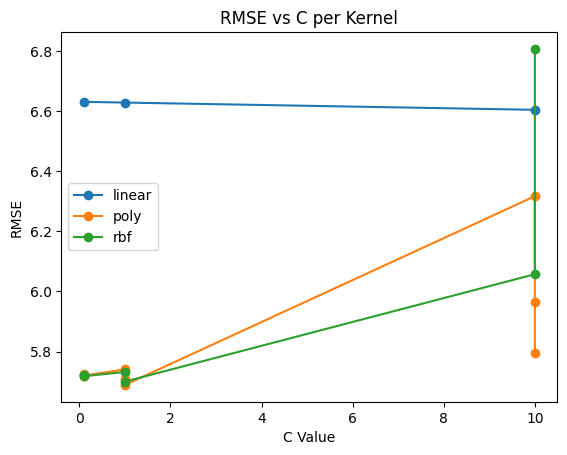

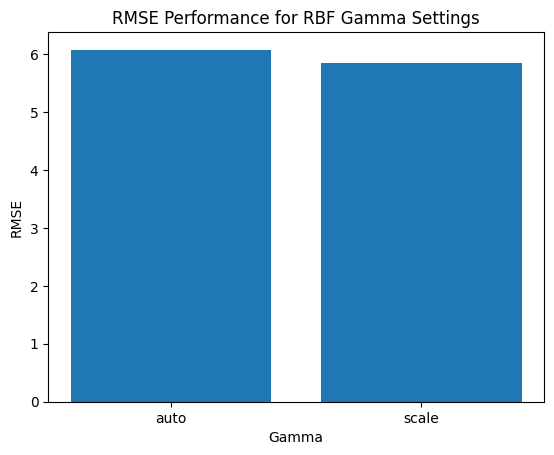

In [74]:
# TODO: Visualize performance vs C/gamma/degree
# Example: line plot of RMSE vs C for a fixed kernel

plt.figure()

for kernel in results_df["kernel"].unique():
    kernel_type = results_df[results_df["kernel"] == kernel]
    plt.plot(kernel_type["C"], kernel_type["rmse"], marker="o", label=kernel)

plt.title("RMSE vs C per Kernel")
plt.xlabel("C Value")
plt.ylabel("RMSE")
plt.legend()
plt.show()

# Example #2 - RMSE performance for different gammas (RBF kernel only)
rbf_df = results_df[results_df["kernel"] == "rbf"]
gamma_rmse = rbf_df.groupby("gamma")["rmse"].mean()
plt.figure()

plt.bar(gamma_recall.index.astype(str), gamma_rmse.values)

plt.xlabel("Gamma")
plt.ylabel("RMSE")
plt.title("RMSE Performance for RBF Gamma Settings")

plt.show()

